# Network Intrusion Detection System (NIDS) — Machine Learning

This notebook builds a machine-learning based Network Intrusion Detection System that
classifies network connections as **Normal** or one of four attack categories:

- **DoS** — Denial of Service (e.g. neptune, smurf, back, teardrop)
- **Probe** — surveillance / scanning (e.g. nmap, portsweep, satan)
- **R2L** — Remote-to-Local, unauthorized access from a remote machine (e.g. guess_passwd, warezmaster)
- **U2R** — User-to-Root, privilege escalation (e.g. buffer_overflow, rootkit)

**Dataset:** [NSL-KDD](https://www.unb.ca/cic/datasets/nsl.html) — the cleaned-up, de-duplicated
successor to the original KDD Cup 1999 dataset. It's the de-facto benchmark for intrusion
detection research.






In [25]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score, confusion_matrix
)

pd.set_option("display.max_columns", 50)
np.random.seed(42)


## Configuration



In [26]:
COLUMN_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty",
]

CATEGORICAL_COLUMNS = ["protocol_type", "service", "flag"]

ATTACK_CATEGORY_MAP = {
    "normal": "Normal",
    # DoS
    "back": "DoS", "land": "DoS", "neptune": "DoS", "pod": "DoS",
    "smurf": "DoS", "teardrop": "DoS", "mailbomb": "DoS",
    "processtable": "DoS", "udpstorm": "DoS", "apache2": "DoS", "worm": "DoS",
    # Probe
    "ipsweep": "Probe", "nmap": "Probe", "portsweep": "Probe",
    "satan": "Probe", "mscan": "Probe", "saint": "Probe",
    # R2L
    "ftp_write": "R2L", "guess_passwd": "R2L", "imap": "R2L",
    "multihop": "R2L", "phf": "R2L", "spy": "R2L", "warezclient": "R2L",
    "warezmaster": "R2L", "xlock": "R2L", "xsnoop": "R2L",
    "snmpguess": "R2L", "snmpgetattack": "R2L", "httptunnel": "R2L",
    "sendmail": "R2L", "named": "R2L",
    # U2R
    "buffer_overflow": "U2R", "loadmodule": "U2R", "perl": "U2R",
    "rootkit": "U2R", "xterm": "U2R", "ps": "U2R", "sqlattack": "U2R",
}

DATA_DIR = "/content/"
RANDOM_STATE = 42

## Load the data

In [27]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "KDDTrain+.txt"), names=COLUMN_NAMES, header=None)
test_df = pd.read_csv(os.path.join(DATA_DIR, "KDDTest+.txt"), names=COLUMN_NAMES, header=None)

print(f"Train: {train_df.shape}, Test: {test_df.shape}")
train_df.head()


Train: (125973, 43), Test: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [28]:
# Map fine-grained labels to the 5 top-level categories
train_df["attack_category"] = train_df["label"].map(ATTACK_CATEGORY_MAP).fillna("Unknown")
test_df["attack_category"] = test_df["label"].map(ATTACK_CATEGORY_MAP).fillna("Unknown")

train_df = train_df[train_df["attack_category"] != "Unknown"].reset_index(drop=True)
test_df = test_df[test_df["attack_category"] != "Unknown"].reset_index(drop=True)

print("Train category counts:")
print(train_df["attack_category"].value_counts())
print("\nTest category counts:")
print(test_df["attack_category"].value_counts())


Train category counts:
attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Test category counts:
attack_category
Normal    9711
DoS       7460
R2L       2885
Probe     2421
U2R         67
Name: count, dtype: int64


## Exploratory data analysis

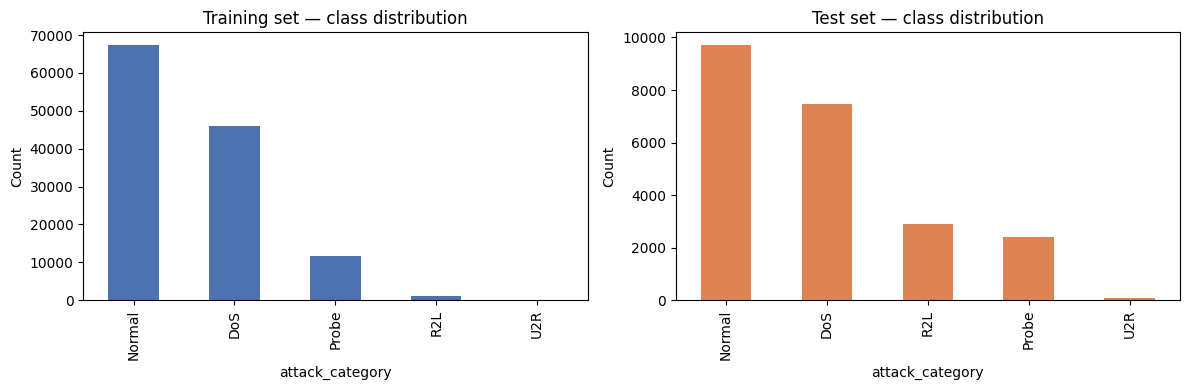

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df["attack_category"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Training set — class distribution")
axes[0].set_ylabel("Count")

test_df["attack_category"].value_counts().plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Test set — class distribution")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


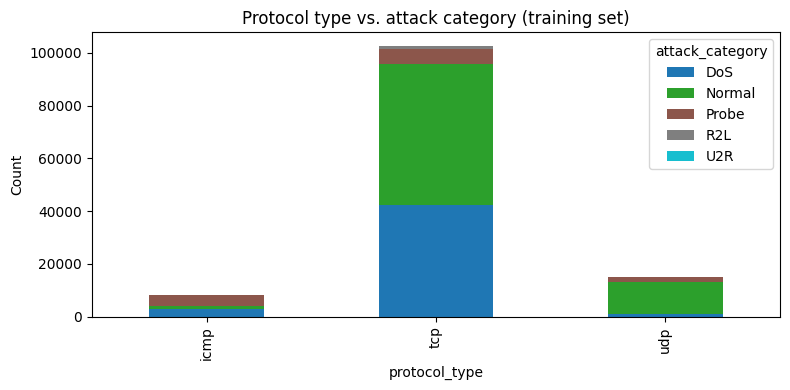

In [30]:
# Protocol type distribution by attack category
protocol_ct = pd.crosstab(train_df["protocol_type"], train_df["attack_category"])
protocol_ct.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="tab10")
plt.title("Protocol type vs. attack category (training set)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Preprocessing



In [31]:
drop_cols = ["label", "difficulty", "attack_category"]

# One-hot encode categorical features; align test columns to train columns
train_cat = pd.get_dummies(train_df[CATEGORICAL_COLUMNS], prefix=CATEGORICAL_COLUMNS)
test_cat = pd.get_dummies(test_df[CATEGORICAL_COLUMNS], prefix=CATEGORICAL_COLUMNS)
test_cat = test_cat.reindex(columns=train_cat.columns, fill_value=0)

numeric_cols = [c for c in train_df.columns if c not in CATEGORICAL_COLUMNS + drop_cols]

scaler = StandardScaler()
train_num_scaled = scaler.fit_transform(train_df[numeric_cols].astype(float))
test_num_scaled = scaler.transform(test_df[numeric_cols].astype(float))

X_train = np.hstack([train_num_scaled, train_cat.values])
X_test = np.hstack([test_num_scaled, test_cat.values])

feature_names = numeric_cols + list(train_cat.columns)

le = LabelEncoder()
y_train = le.fit_transform(train_df["attack_category"])

class_to_idx = {c: i for i, c in enumerate(le.classes_)}
y_test = test_df["attack_category"].map(class_to_idx).fillna(-1).astype(int).values

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Classes: {list(le.classes_)}")


X_train: (125973, 122), X_test: (22544, 122)
Classes: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']


## Train the model


In [32]:
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)
rf.fit(X_train, y_train)

print(f"Trained in {time.time() - t0:.1f}s")


Trained in 32.5s


## Evaluate

In [33]:
mask = y_test != -1
y_pred = rf.predict(X_test[mask])
y_true = y_test[mask]

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="macro")

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {f1:.4f}\n")
print(classification_report(y_true, y_pred, target_names=list(le.classes_), digits=3, zero_division=0))


Accuracy: 0.7367
Macro F1: 0.4716

              precision    recall  f1-score   support

         DoS      0.961     0.764     0.851      7460
      Normal      0.634     0.974     0.768      9711
       Probe      0.851     0.596     0.701      2421
         R2L      0.812     0.005     0.009      2885
         U2R      0.333     0.015     0.029        67

    accuracy                          0.737     22544
   macro avg      0.719     0.470     0.472     22544
weighted avg      0.788     0.737     0.689     22544



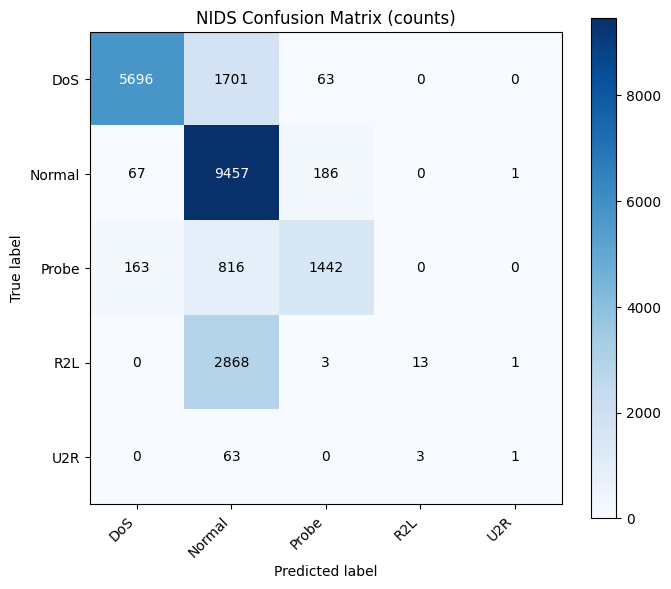

In [34]:
cm = confusion_matrix(y_true, y_pred)
class_names = list(le.classes_)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("NIDS Confusion Matrix (counts)")

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

fig.colorbar(im)
fig.tight_layout()
plt.show()


**Note on R2L / U2R recall:** NSL-KDD's official test set deliberately includes
attack *subtypes* that never appear in the training set, specifically to test
generalization to unseen attacks. This is why R2L and U2R recall typically looks much
lower than DoS/Probe/Normal — it's a well-documented property of this benchmark, not a
bug in the model. If you want a more "typical accuracy" demo, you can build a random
train/test split from the combined data instead of using the official split.

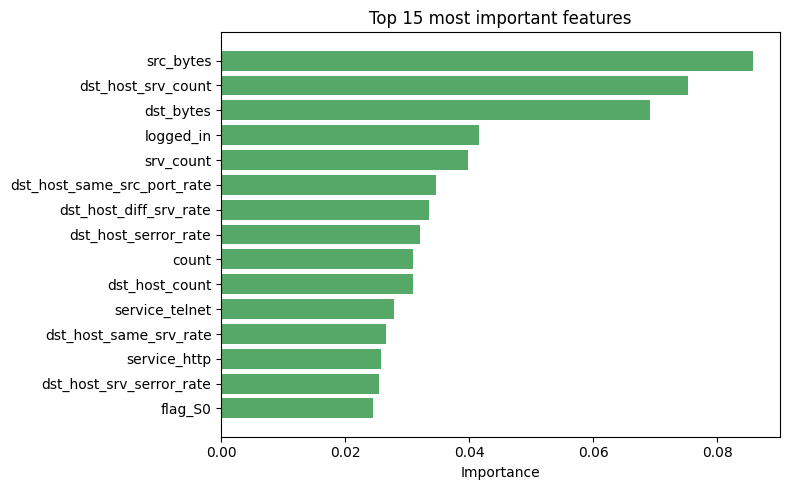

In [35]:
importances = rf.feature_importances_
top_idx = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(8, 5))
plt.barh([feature_names[i] for i in top_idx][::-1], importances[top_idx][::-1], color="#55A868")
plt.title("Top 15 most important features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## Run inference on new traffic

In [36]:
sample = test_df.sample(10, random_state=7)
sample_cat = pd.get_dummies(sample[CATEGORICAL_COLUMNS], prefix=CATEGORICAL_COLUMNS)
sample_cat = sample_cat.reindex(columns=train_cat.columns, fill_value=0)
sample_num_scaled = scaler.transform(sample[numeric_cols].astype(float))
X_sample = np.hstack([sample_num_scaled, sample_cat.values])

pred = rf.predict(X_sample)
pred_labels = le.inverse_transform(pred)
proba = rf.predict_proba(X_sample)

results = pd.DataFrame({
    "predicted_category": pred_labels,
    "confidence": proba.max(axis=1).round(3),
    "actual_label": sample["label"].values,
    "actual_category": sample["attack_category"].values,
})
results


,predicted_category,confidence,actual_label,actual_category
0,Normal,0.980,normal,Normal
1,Normal,1.000,normal,Normal
2,Normal,1.000,normal,Normal
3,Normal,0.990,normal,Normal
4,Normal,1.000,normal,Normal
5,Normal,0.930,snmpguess,R2L
6,Normal,1.000,normal,Normal
7,Normal,1.000,snmpgetattack,R2L
8,Normal,0.695,mscan,Probe
9,Normal,0.805,processtable,DoS


## Preprocessing artifacts of saved trained model

In [37]:
os.makedirs("models", exist_ok=True)

joblib.dump(rf, "models/best_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(le, "models/label_encoder.pkl")
joblib.dump(feature_names, "models/feature_names.pkl")

print("Saved model + preprocessing artifacts to models/")


Saved model + preprocessing artifacts to models/
